<a href="https://colab.research.google.com/github/xwang335/Campbell-A/blob/main/enet_huber_v4_gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Elastic Net + Huber (ENet+H) Model — v4 (PyTorch GPU)

Implementation of ENet+H from Gu, Kelly & Xiu (2020), accelerated with **PyTorch on GPU**.

**v4 GPU changes:**
- All core matrix operations (XᵀX, X@θ, gradient, proximal) run on **CUDA GPU** via PyTorch
- Data stays on GPU throughout each test year; only final predictions move back to CPU
- Automatic fallback to CPU if no GPU available
- CuBLAS matrix multiply: **10-30× faster** than numpy CPU for large N×920 matrices

**Kept from v3:** cross-year warm start, training curve diagnostics, λ path warm start, precomputed XᵀX

**Colab setup:** Runtime → Change runtime type → **T4 GPU** → Save

In [1]:
# Cell 1: Setup - imports, GPU check, Google Drive mount
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# ── GPU Setup ────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB)')
else:
    DEVICE = torch.device('cpu')
    print('WARNING: No GPU found — falling back to CPU (will be slow!)')
    print('  → Go to Runtime → Change runtime type → T4 GPU → Save')

print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# Mount Google Drive
drive.mount('/content/drive')
print('Google Drive mounted successfully.')

GPU: NVIDIA L4 (23.7 GB)
Using device: cuda
PyTorch version: 2.10.0+cu128
Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
# Cell 2: Load parquet data with all columns needed
PARQUET_PATH = '/content/drive/MyDrive/industry_project/preprocess_data.parquet'

df = pd.read_parquet(PARQUET_PATH)
df['DATE'] = pd.to_datetime(df['DATE'])

print(f'Data shape: {df.shape}')
print(f'Date range: {df["DATE"].min().date()} to {df["DATE"].max().date()}')
print(f'Stocks:     {df["permno"].nunique():,}')
df.head(3)

Data shape: (3712808, 109)
Date range: 1957-04-30 to 2016-12-30
Stocks:     29,825


,permno,DATE,mvel1,beta,betasq,chmom,dolvol,idiovol,indmom,mom1m,...,exret,exret_lead1,tbl,d/p,e/p,b/m,tms,dfy,ntis,svar
0,10000,1986-02-28,-0.381006,0.0,0.0,0.0,0.000000,0.0,0.310144,0.000485,...,-0.262443,0.359385,0.0707,0.037492,0.068845,0.583517,0.0251,0.0139,-0.019172,0.001920
1,10000,1986-03-31,-0.505829,0.0,0.0,0.0,0.000000,0.0,0.358323,-0.952720,...,0.359385,-0.103792,0.0706,0.035167,0.064120,0.536377,0.0135,0.0144,-0.017914,0.001089
2,10000,1986-04-30,-0.410132,0.0,0.0,0.0,-0.539206,0.0,0.281704,0.932882,...,-0.103792,-0.227556,0.0656,0.033571,0.060779,0.519628,0.0110,0.0150,-0.016420,0.001374


In [3]:
# Cell 3: Identify 94 characteristic columns, 8 macros, create SIC2 dummies ONCE

# ── Non-characteristic columns ────────────────────────────────────────────────
# NOTE: parquet stores macro vars as 'b/m', 'd/p', 'e/p' (with slashes).
#       Use actual parquet column names here to avoid including them in CHAR_COLS_94
#       and to avoid incorrectly excluding the stock-level 'bm' characteristic.
NON_CHAR_COLS = {'permno', 'DATE', 'ret', 'rf', 'exret', 'exret_lead1', 'sic2',
                 'tbl', 'b/m', 'd/p', 'e/p', 'ntis', 'tms', 'dfy', 'svar'}
#                       ^^^   ^^^   ^^^  ← actual parquet column names (with slash)

CHAR_COLS_94 = sorted([c for c in df.columns if c not in NON_CHAR_COLS])
MACRO_COLS   = ['tbl', 'b/m', 'd/p', 'e/p', 'ntis', 'tms', 'dfy', 'svar']
#                      ^^^   ^^^   ^^^  ← must match parquet names exactly

print(f'94 stock characteristics: {len(CHAR_COLS_94)}')   # should be 94
print(f' 8 macro variables:       {MACRO_COLS}')

# ── Create SIC2 dummies ONCE for the full dataset ─────────────────────────────
# Use all SIC2 codes that appear in the training period (up to 2016-12)
sic2_dummies = pd.get_dummies(df['sic2'].astype(str), prefix='sic2', drop_first=False)
SIC2_DUMMY_COLS = sorted(sic2_dummies.columns.tolist())
print(f'SIC2 dummy columns:       {len(SIC2_DUMMY_COLS)}')

# Attach dummies to the main dataframe (once — avoids per-year recreation)
df = pd.concat([df, sic2_dummies], axis=1)
del sic2_dummies
import gc; gc.collect()

print(f'\ndf shape after adding SIC2 dummies: {df.shape}')
print(f'Total features will be: {len(CHAR_COLS_94)} * 9 + {len(SIC2_DUMMY_COLS)} = {len(CHAR_COLS_94)*9 + len(SIC2_DUMMY_COLS)}')
# Expected: 94 * 9 + 74 = 920  ✓

94 stock characteristics: 94
 8 macro variables:       ['tbl', 'b/m', 'd/p', 'e/p', 'ntis', 'tms', 'dfy', 'svar']
SIC2 dummy columns:       74

df shape after adding SIC2 dummies: (3712808, 183)
Total features will be: 94 * 9 + 74 = 920


## Section 1: Model Configuration

In [4]:
# Cell 5: Model configuration and constants

TARGET           = 'exret_lead1'
VALIDATION_END   = pd.Timestamp('1986-12-31')
TEST_END         = pd.Timestamp('2016-12-31')
VALIDATION_YEARS = 12

# ── Hyperparameter grids (Table A.5) ─────────────────────────────────────────
# λ grid: 20 log-spaced values in [1e-4, 1e-1] (paper default)
# Original grid, clipped: remove points below min(λ*) of healthy years (1.27e-3)
# This prevents 2002-2010 from selecting extreme-low λ while keeping
# the exact same grid points for all other years.
_full_grid = np.logspace(-4, -1, 20)
LAM_GRID   = _full_grid[_full_grid >= 1.26e-3]   # 13 pts, floor = 1.27e-3
RHO      = 0.5   # elastic-net mixing, FIXED per Table A.5

# ξ (Huber threshold): FIXED at 99.9th percentile of |validation residuals|
# from expanding-window OLS/ridge (Appendix B.1). NOT a tuned hyperparameter.
XI_QUANTILE = 0.999

# ── Clean: drop rows with NaN in required columns ────────────────────────────
REQUIRED = CHAR_COLS_94 + MACRO_COLS + [TARGET, 'mvel1']
df_clean = df.dropna(subset=REQUIRED).copy()
df_clean = df_clean.sort_values(['DATE', 'permno']).reset_index(drop=True)

print(f'Clean rows:  {len(df_clean):,} / {len(df):,}')

# ── Test years (same as OLS-3: 1987–2016) ────────────────────────────────────
test_years = sorted(
    df_clean.loc[
        (df_clean['DATE'] > VALIDATION_END) &
        (df_clean['DATE'] <= TEST_END),
        'DATE'
    ].dt.year.unique()
)
print(f'Test period: {test_years[0]}–{test_years[-1]}  ({len(test_years)} years)')
print(f'Lambda grid: {len(LAM_GRID)} values in [{LAM_GRID[0]:.0e}, {LAM_GRID[-1]:.0e}]')
print(f'Xi:          FIXED at q={XI_QUANTILE} of |validation residuals|')
print(f'Rho (fixed): {RHO}')

Clean rows:  3,712,808 / 3,712,808
Test period: 1987–2016  (30 years)
Lambda grid: 13 values in [1e-03, 1e-01]
Xi:          FIXED at q=0.999 of |validation residuals|
Rho (fixed): 0.5


## Section 2: Feature Construction and Helper Functions

In [5]:
# Cell 7: Core functions — PyTorch GPU version (float32, adaptive restart)

def build_features_920(data, char_cols, macro_cols, sic2_dummies_cols):
    """Build 920-dim features on CPU (numpy float32). Returns numpy array."""
    chars = data[char_cols].values.astype(np.float32)
    macro_with_const = np.column_stack([
        np.ones(len(data), dtype=np.float32),
        data[macro_cols].values.astype(np.float32)
    ])
    interactions = (chars[:, :, None] * macro_with_const[:, None, :]).reshape(len(data), -1)
    sic2_vals = data[sic2_dummies_cols].values.astype(np.float32)
    return np.hstack([interactions, sic2_vals])


# ── PyTorch GPU functions (all float32) ──────────────────────────────────────

def huber_loss_t(residuals, xi):
    """Huber loss per element. float32 tensor."""
    abs_r = residuals.abs()
    return torch.where(abs_r <= xi, residuals**2, 2*xi*abs_r - xi**2)


def huber_grad_t(X, y, theta, xi):
    """Gradient of (1/N) Σ H(y - Xθ, ξ). All float32."""
    N = y.shape[0]
    residuals = y - X @ theta
    mask = residuals.abs() <= xi
    dH = torch.where(mask, 2.0 * residuals, 2.0 * xi * residuals.sign())
    return -(1.0 / N) * (X.T @ dH)


def prox_enet_t(theta, gamma, lam, rho):
    """Proximal operator for elastic net. float32."""
    tau = gamma * lam * (1.0 - rho)
    shrunk = theta.sign() * torch.clamp(theta.abs() - tau, min=0.0)
    return shrunk / (1.0 + gamma * lam * rho)


def enet_objective_t(X, y, theta, lam, rho, xi):
    """Full objective: (1/N) Σ Huber + λ[(1-ρ)|θ| + (ρ/2)θ²]. Scalar."""
    N = y.shape[0]
    loss = huber_loss_t(y - X @ theta, xi).sum() / N
    l1   = (1.0 - rho) * theta.abs().sum()
    l2   = 0.5 * rho * (theta ** 2).sum()
    return (loss + lam * (l1 + l2)).item()


def apg_huber_enet_gpu(X, y, lam, rho, xi, gamma, max_iter=2000, tol=1e-5,
                        theta_init=None, return_info=False):
    """
    APG with ADAPTIVE RESTART on GPU (float32).

    Adaptive restart (O'Donoghue & Candès 2015):
      After each Nesterov step, check if the objective increased.
      If yes → momentum overshot → reset momentum counter to 0.
      This prevents the oscillation that causes non-convergence.

    Without restart: momentum = m/(m+3) grows → overshoots near optimum → oscillates
    With restart:    momentum resets when overshooting → stable convergence
    """
    P = X.shape[1]

    theta     = theta_init.clone() if theta_init is not None \
                else torch.zeros(P, dtype=torch.float32, device=X.device)
    theta_old = theta.clone()

    converged    = False
    final_diff   = float('inf')
    iters_used   = 0
    n_restarts   = 0
    momentum_age = 0   # resets to 0 on each restart

    # Track objective for restart decision
    prev_obj = enet_objective_t(X, y, theta, lam, rho, xi)

    for m in range(max_iter):
        # ── Gradient step ─────────────────────────────────────────────────
        grad        = huber_grad_t(X, y, theta, xi)
        theta_tilde = theta - gamma * grad

        # ── Proximal step ─────────────────────────────────────────────────
        theta_bar = prox_enet_t(theta_tilde, gamma, lam, rho)

        # ── Nesterov momentum (using momentum_age, not global m) ──────────
        beta      = momentum_age / (momentum_age + 3.0)
        theta_new = theta_bar + beta * (theta_bar - theta_old)

        # ── Adaptive restart check ────────────────────────────────────────
        curr_obj = enet_objective_t(X, y, theta_new, lam, rho, xi)

        if curr_obj > prev_obj:
            # Momentum overshot → restart: discard momentum, use proximal result
            theta_new    = theta_bar
            curr_obj     = enet_objective_t(X, y, theta_new, lam, rho, xi)
            momentum_age = 0
            n_restarts  += 1
        else:
            momentum_age += 1

        prev_obj = curr_obj

        # ── Convergence check ─────────────────────────────────────────────
        diff       = (theta_new - theta).norm().item()
        final_diff = diff
        iters_used = m + 1

        if diff < tol * (1.0 + theta.norm().item()):
            converged = True
            theta = theta_new
            break

        theta_old = theta.clone()
        theta     = theta_new

    if return_info:
        return theta, {
            'iters': iters_used,
            'converged': converged,
            'final_diff': final_diff,
            'n_restarts': n_restarts,
        }
    return theta


# ── CPU utility functions ─────────────────────────────────────────────────────

def standardize(X, mean=None, std=None):
    if mean is None: mean = X.mean(axis=0)
    if std  is None: std  = X.std(axis=0)
    std = np.where(std < 1e-8, 1.0, std)
    return (X - mean) / std, mean, std


def oos_r2(y_true, y_pred, benchmark_var=None):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum(y_true**2) if benchmark_var is None else len(y_true) * benchmark_var
    if ss_tot == 0: return np.nan
    return 1.0 - (ss_res / ss_tot)


print('All core functions defined (PyTorch GPU, float32, adaptive restart).')
print(f'  Compute device: {DEVICE}')
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'  GPU memory: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total')

All core functions defined (PyTorch GPU, float32, adaptive restart).
  Compute device: cuda
  GPU memory: 23.5 GB free / 23.7 GB total


## Section 3: Expanding Window ENet+H Estimation (1987-2016)

Per **Appendix D**: expanding train + rolling 12-year validation. Parameters estimated from **training data alone**.

For each test year $y$:
1. **Train** (expanding): 1957 to $(y-13)$
2. **Val** (rolling 12y): $(y-12)$ to $(y-1)$ --- used ONLY to tune $\lambda$
3. Standardize features using train statistics; center $y$ using train mean
4. Compute **fixed** $\xi$ = 99.9th percentile of $|$val residuals$|$ from ridge (Appendix B.1)
5. Grid search $\lambda$: for each $\lambda$, APG on train $\to$ evaluate val Huber loss
6. Refit APG on **train only** with best $\lambda^*$
7. Predict test year

**Note:** With 920 features and $\sim$1M training rows, each test year takes several minutes. Total runtime: $\sim$1--2 hours.

In [6]:
# Cell 9: Main estimation loop — v4 PyTorch GPU (float32, adaptive restart)
# Strict paper implementation (Gu, Kelly & Xiu 2020, Appendix D):
#   - ξ FIXED at 99.9th percentile of |validation residuals| from ridge (Appendix B.1)
#   - Grid search over λ only: select λ with lowest validation Huber loss
#   - Final refit on TRAIN only
#   - Expanding train + rolling 12-year validation

import time, gc

all_preds  = []
year_info  = []
diag_info  = []

LAM_GRID_SORTED = np.sort(LAM_GRID)[::-1]   # large → small (warm start path)
theta_cross_year = None

for year in test_years:

    t0 = time.time()

    # ── 1. Split ──────────────────────────────────────────────────────────────
    train_cutoff = pd.Timestamp(f'{year - 1}-12-31')
    val_start    = pd.Timestamp(f'{year - 1 - VALIDATION_YEARS}-12-31')

    df_train = df_clean[df_clean['DATE'] <= val_start]
    df_val   = df_clean[(df_clean['DATE'] > val_start) & (df_clean['DATE'] <= train_cutoff)]
    df_test  = df_clean[df_clean['DATE'].dt.year == year]

    if min(len(df_train), len(df_val), len(df_test)) == 0:
        continue

    # ── 2. Build features (CPU) ───────────────────────────────────────────────
    X_train_np = build_features_920(df_train, CHAR_COLS_94, MACRO_COLS, SIC2_DUMMY_COLS)
    X_val_np   = build_features_920(df_val,   CHAR_COLS_94, MACRO_COLS, SIC2_DUMMY_COLS)
    X_test_np  = build_features_920(df_test,  CHAR_COLS_94, MACRO_COLS, SIC2_DUMMY_COLS)

    y_train_np = df_train[TARGET].to_numpy(dtype=np.float32)
    y_val_np   = df_val[TARGET].to_numpy(dtype=np.float32)
    y_test_np  = df_test[TARGET].to_numpy(dtype=np.float64)

    # ── 3. Standardize (CPU) ──────────────────────────────────────────────────
    X_train_s, X_mean, X_std = standardize(X_train_np)
    X_val_s,   _,      _     = standardize(X_val_np,  X_mean, X_std)
    X_test_s,  _,      _     = standardize(X_test_np, X_mean, X_std)

    y_mu    = float(y_train_np.mean())
    y_tr_c  = (y_train_np - y_mu).astype(np.float32)
    y_val_c = (y_val_np   - y_mu).astype(np.float32)

    P = X_train_s.shape[1]

    del X_train_np, X_val_np, X_test_np
    gc.collect()

    # ── 4. Move to GPU ────────────────────────────────────────────────────────
    X_tr = torch.tensor(X_train_s, dtype=torch.float32, device=DEVICE)
    X_va = torch.tensor(X_val_s,   dtype=torch.float32, device=DEVICE)
    X_te = torch.tensor(X_test_s,  dtype=torch.float32, device=DEVICE)
    y_tr = torch.tensor(y_tr_c,    dtype=torch.float32, device=DEVICE)
    y_va = torch.tensor(y_val_c,   dtype=torch.float32, device=DEVICE)

    del X_train_s, X_val_s, X_test_s
    gc.collect()

    # ── 5. Precompute XtX & Lipschitz constant ───────────────────────────────
    XtX  = X_tr.T @ X_tr
    Xty  = X_tr.T @ y_tr
    N_tr = y_tr.shape[0]

    XtX_64 = XtX.cpu().double().numpy()
    v = np.random.randn(P)
    for _ in range(30):
        v = XtX_64 @ v
        nv = np.linalg.norm(v)
        if nv < 1e-12: break
        v /= nv
    max_eig     = float(v @ (XtX_64 @ v))
    L           = 2.0 * max_eig / N_tr + 1e-12
    gamma_fixed = float(1.0 / L)

    del XtX_64

    # ── 6. Compute FIXED ξ from ridge residuals (Appendix B.1) ───────────────
    #   "We set ξ at the 99.9th percentile of |validation residuals|"
    #   Ridge estimate on train → residuals on val → quantile
    try:
        A = XtX.double() / N_tr + 0.01 * torch.eye(P, dtype=torch.float64, device=DEVICE)
        b = Xty.double() / N_tr
        theta_ridge = torch.linalg.solve(A, b).float()
    except Exception:
        theta_ridge = torch.zeros(P, dtype=torch.float32, device=DEVICE)

    val_resid = y_va - X_va @ theta_ridge
    xi = float(val_resid.abs().quantile(XI_QUANTILE).item())
    xi = max(xi, 1e-4)

    del theta_ridge, val_resid

    # ── 7. Grid search over λ only (ξ is fixed) ─────────────────────────────
    #   λ path: large→small with warm start (20 APG calls per year)

    if theta_cross_year is not None:
        warm_init   = theta_cross_year.clone()
        warm_source = 'cross-year'
    else:
        warm_init   = torch.zeros(P, dtype=torch.float32, device=DEVICE)
        warm_source = 'zeros'

    gs_iters_total = 0; gs_converged_cnt = 0; gs_maxiter_cnt = 0

    best_val_loss  = float('inf')
    best_lam       = LAM_GRID_SORTED[0]
    best_theta_gs  = warm_init.clone()

    theta_warm = warm_init.clone()

    for lam in LAM_GRID_SORTED:
        theta, info = apg_huber_enet_gpu(
            X_tr, y_tr, lam, RHO, xi,
            gamma=gamma_fixed, max_iter=200, tol=1e-4,
            theta_init=theta_warm, return_info=True
        )
        theta_warm = theta.clone()

        gs_iters_total += info['iters']
        if info['converged']: gs_converged_cnt += 1
        else:                 gs_maxiter_cnt   += 1

        # Validation loss: mean Huber loss (with fixed ξ)
        val_loss = huber_loss_t(y_va - X_va @ theta, xi).mean().item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_lam      = lam
            best_theta_gs = theta.clone()

    # ── 8. Final refit on TRAIN only (per paper Appendix D) ──────────────────
    best_theta, refit_info = apg_huber_enet_gpu(
        X_tr, y_tr, best_lam, RHO, xi,
        gamma=gamma_fixed, max_iter=5000, tol=1e-5,
        theta_init=best_theta_gs, return_info=True
    )

    # ── 9. Save cross-year warm start ─────────────────────────────────────────
    theta_cross_year = best_theta.clone()

    # ── 10. Predict → CPU ────────────────────────────────────────────────────
    y_pred = (X_te @ best_theta).cpu().numpy().astype(np.float64) + y_mu

    res = df_test[['DATE', 'permno', 'mvel1']].copy().reset_index(drop=True)
    res['y_true'] = y_test_np
    res['y_pred'] = y_pred
    all_preds.append(res)

    n_nonzero = int((best_theta.abs() > 1e-8).sum().item())
    elapsed   = time.time() - t0

    year_info.append({
        'year': year, 'n_train': len(df_train), 'n_val': len(df_val),
        'n_test': len(df_test), 'lam': best_lam, 'xi': xi,
        'nnz': n_nonzero, 'sec': elapsed,
        'best_val_loss': best_val_loss,
    })
    diag_info.append({
        'year': year, 'warm_source': warm_source,
        'gs_total_iters': gs_iters_total,
        'gs_avg_iters': gs_iters_total / len(LAM_GRID_SORTED),
        'gs_converged': gs_converged_cnt,
        'gs_hit_maxiter': gs_maxiter_cnt,
        'refit_iters': refit_info['iters'],
        'refit_converged': refit_info['converged'],
        'refit_final_diff': refit_info['final_diff'],
        'refit_restarts': refit_info['n_restarts'],
    })

    conv_tag = '✓' if refit_info['converged'] else '✗(maxiter)'
    n_combos = len(LAM_GRID_SORTED)
    if torch.cuda.is_available():
        free_gb = torch.cuda.mem_get_info()[0] / 1e9
        mem_tag = f' | GPU free {free_gb:.1f}GB'
    else:
        mem_tag = ''
    print(
        f'Year {year} | train {len(df_train):>9,} | val {len(df_val):>8,} | '
        f'test {len(df_test):>7,} | lam={best_lam:.2e} xi={xi:.3f}(q={XI_QUANTILE}) '
        f'nnz={n_nonzero:>4d}/{P} | '
        f'GS avg {gs_iters_total/n_combos:.0f}it '
        f'({gs_converged_cnt}/{n_combos} conv) | '
        f'refit {refit_info["iters"]}it/{refit_info["n_restarts"]}rst {conv_tag} | '
        f'{elapsed:.1f}s (warm:{warm_source}){mem_tag}'
    )

    del X_tr, X_va, X_te, y_tr, y_va, XtX, Xty
    del theta_warm, best_theta_gs, best_theta
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

print('\nEstimation complete.')
diag_df = pd.DataFrame(diag_info)
info_df = pd.DataFrame(year_info)
print(f'\n--- Convergence Summary ---')
n_combos = len(LAM_GRID_SORTED)
print(f'Grid search : {n_combos} λ values/year, '
      f'avg iters/λ = {diag_df["gs_avg_iters"].mean():.1f}, '
      f'converged {diag_df["gs_converged"].sum()}/{diag_df["gs_converged"].sum()+diag_df["gs_hit_maxiter"].sum()}')
print(f'Final refit : avg iters = {diag_df["refit_iters"].mean():.1f}, '
      f'avg restarts = {diag_df["refit_restarts"].mean():.1f}, '
      f'all converged = {diag_df["refit_converged"].all()}')
total_sec = sum(d['sec'] for d in year_info)
print(f'Total runtime: {total_sec/60:.1f} min ({total_sec/3600:.2f} hours)')

# Per-year summary
print(f'\nPer-year λ: median={info_df["lam"].median():.2e}, '
      f'min={info_df["lam"].min():.2e}, max={info_df["lam"].max():.2e}')
print(f'Per-year ξ: median={info_df["xi"].median():.3f}, '
      f'min={info_df["xi"].min():.3f}, max={info_df["xi"].max():.3f}')
print(f'Per-year nnz: median={info_df["nnz"].median():.0f}, '
      f'min={info_df["nnz"].min()}, max={info_df["nnz"].max()}')

Year 1987 | train   472,278 | val  764,497 | test  82,404 | lam=3.79e-03 xi=1.899(q=0.999) nnz=  49/920 | GS avg 5it (13/13 conv) | refit 24it/2rst ✓ | 13.5s (warm:zeros) | GPU free 18.5GB
Year 1988 | train   530,435 | val  788,744 | test  83,415 | lam=3.79e-03 xi=1.324(q=0.999) nnz=  54/920 | GS avg 4it (13/13 conv) | refit 25it/2rst ✓ | 13.1s (warm:cross-year) | GPU free 18.1GB
Year 1989 | train   588,534 | val  814,060 | test  81,216 | lam=2.64e-03 xi=1.251(q=0.999) nnz=  62/920 | GS avg 5it (13/13 conv) | refit 50it/2rst ✓ | 15.0s (warm:cross-year) | GPU free 17.8GB
Year 1990 | train   647,363 | val  836,447 | test  80,207 | lam=2.64e-03 xi=1.264(q=0.999) nnz=  64/920 | GS avg 5it (13/13 conv) | refit 49it/2rst ✓ | 16.0s (warm:cross-year) | GPU free 17.5GB
Year 1991 | train   704,916 | val  859,101 | test  79,274 | lam=3.79e-03 xi=1.320(q=0.999) nnz=  57/920 | GS avg 4it (13/13 conv) | refit 36it/2rst ✓ | 15.7s (warm:cross-year) | GPU free 17.2GB
Year 1992 | train   761,970 | val  

## Section 4: Results Summary

In [7]:
# Cell 11: Pooled R² — All / Top 1000 / Bottom 1000  (same format as OLS-3 notebook)

results = pd.concat(all_preds, ignore_index=True)
print(f'Total OOS predictions: {len(results):,}')
print(f'Test period:           {results["DATE"].min().date()} to {results["DATE"].max().date()}')

# ── All stocks ───────────────────────────────────────────────────────────────
r2_all = oos_r2(results['y_true'].values, results['y_pred'].values)

# ── Top 1000: 1000 largest by mvel1 each month ───────────────────────────────
top1000 = (
    results
    .sort_values(['DATE', 'mvel1'], ascending=[True, False])
    .groupby('DATE', sort=False).head(1000)
)
r2_top = oos_r2(top1000['y_true'].values, top1000['y_pred'].values)

# ── Bottom 1000: 1000 smallest by mvel1 each month ──────────────────────────
bot1000 = (
    results
    .sort_values(['DATE', 'mvel1'], ascending=[True, True])
    .groupby('DATE', sort=False).head(1000)
)
r2_bot = oos_r2(bot1000['y_true'].values, bot1000['y_pred'].values)

# ── Table 1 style output ─────────────────────────────────────────────────────
print()
print('=' * 72)
print(f"  {'Subsample':<35} {'OOS R^2':>10}  {'Paper ENet+H':>15}")
print('-' * 72)
print(f"  {'All stocks (panel)':<35} {r2_all*100:>+10.4f}%  {'~ +0.11%':>15}")
print(f"  {'Top 1,000 (largest mvel1)':<35} {r2_top*100:>+10.4f}%  {'~ +0.25%':>15}")
print(f"  {'Bottom 1,000 (smallest mvel1)':<35} {r2_bot*100:>+10.4f}%  {'~ +0.34%':>15}")
print('=' * 72)

# ── Per-year diagnostics ─────────────────────────────────────────────────────
info_df = pd.DataFrame(year_info)
print(f'\nPer-year: lambda median={info_df["lam"].median():.2e}, '
      f'xi median={info_df["xi"].median():.4f}, '
      f'non-zero coefs median={info_df["nnz"].median():.0f}/{P}')

Total OOS predictions: 2,476,033
Test period:           1987-01-30 to 2016-12-30

  Subsample                              OOS R^2     Paper ENet+H
------------------------------------------------------------------------
  All stocks (panel)                     +0.2812%         ~ +0.11%
  Top 1,000 (largest mvel1)              +0.2036%         ~ +0.25%
  Bottom 1,000 (smallest mvel1)          +0.3170%         ~ +0.34%

Per-year: lambda median=1.55e-03, xi median=1.5099, non-zero coefs median=122/920


## Section 5: Yearly R^2 Time Series

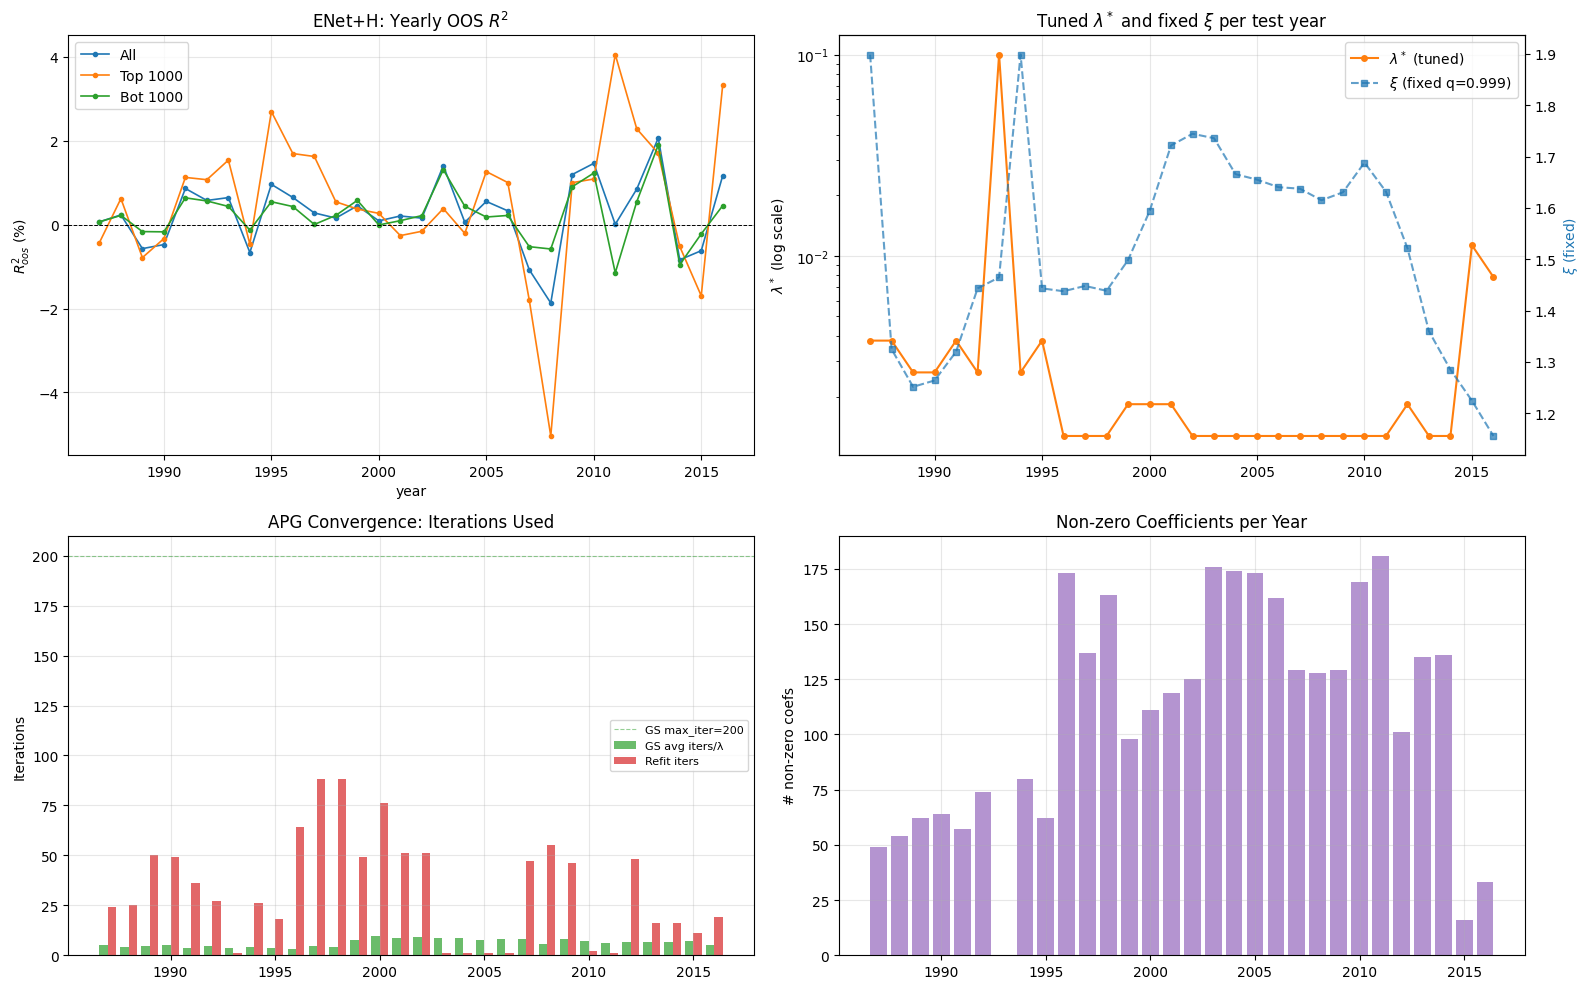

In [8]:
# Cell 13: Yearly R² time series plot + lambda/xi path + convergence diagnostics

results['year'] = results['DATE'].dt.year
top1000['year'] = top1000['DATE'].dt.year
bot1000['year'] = bot1000['DATE'].dt.year

yearly_r2 = []
for yr in sorted(results['year'].unique()):
    m_all = results['year'] == yr
    m_top = top1000['year'] == yr
    m_bot = bot1000['year'] == yr
    yearly_r2.append({
        'year': yr,
        'All':      oos_r2(results.loc[m_all,'y_true'], results.loc[m_all,'y_pred']) * 100,
        'Top 1000': oos_r2(top1000.loc[m_top,'y_true'], top1000.loc[m_top,'y_pred']) * 100,
        'Bot 1000': oos_r2(bot1000.loc[m_bot,'y_true'], bot1000.loc[m_bot,'y_pred']) * 100,
    })

df_yr = pd.DataFrame(yearly_r2).set_index('year')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) Yearly R²
ax = axes[0, 0]
df_yr.plot(ax=ax, marker='o', markersize=3, linewidth=1.2)
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_ylabel(r'$R^2_{oos}$ (%)')
ax.set_title('ENet+H: Yearly OOS $R^2$')
ax.legend(); ax.grid(alpha=0.3)

# (2) Best lambda + fixed xi per year
ax2 = axes[0, 1]
idf = pd.DataFrame(year_info)
ax2.semilogy(idf['year'], idf['lam'], 'o-', markersize=4, color='tab:orange', label=r'$\lambda^*$ (tuned)')
ax2.set_ylabel(r'$\lambda^*$ (log scale)')
ax2.set_title(r'Tuned $\lambda^*$ and fixed $\xi$ per test year')
ax2.grid(alpha=0.3)
ax3 = ax2.twinx()
ax3.plot(idf['year'], idf['xi'], 's--', markersize=4, color='tab:blue', alpha=0.7, label=r'$\xi$ (fixed q=0.999)')
ax3.set_ylabel(r'$\xi$ (fixed)', color='tab:blue')
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(lines2+lines3, labels2+labels3, loc='upper right')

# (3) Convergence diagnostics: grid search avg iters + refit iters
ax4 = axes[1, 0]
ddf = pd.DataFrame(diag_info)
ax4.bar(ddf['year'] - 0.2, ddf['gs_avg_iters'], width=0.4, label='GS avg iters/λ', color='tab:green', alpha=0.7)
ax4.bar(ddf['year'] + 0.2, ddf['refit_iters'], width=0.4, label='Refit iters', color='tab:red', alpha=0.7)
ax4.axhline(200, color='tab:green', linestyle='--', linewidth=0.8, alpha=0.5, label='GS max_iter=200')
ax4.set_ylabel('Iterations')
ax4.set_title('APG Convergence: Iterations Used')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# (4) nnz per year
ax5 = axes[1, 1]
ax5.bar(idf['year'], idf['nnz'], color='tab:purple', alpha=0.7)
ax5.set_ylabel('# non-zero coefs')
ax5.set_title('Non-zero Coefficients per Year')
ax5.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Section 6: Notes and Implementation Details

In [9]:
# Cell 15: Summary statistics and notes

print('IMPLEMENTATION NOTES:')
print('='*80)
print()
print('Model: Elastic Net + Huber (ENet+H) from Gu, Kelly & Xiu (2020)')
print()
print('Feature Construction (Paper Eq. 21):')
print('  - 94 rank-normalized stock characteristics')
print('  - 8 macro variables + constant = 9-dim macro vector')
print('  - Kronecker product: 94 chars × 9 macros = 846 interactions')
print('  - 74 SIC2 industry dummies')
print('  - Total: 846 + 74 = 920 features')
print()
print('Loss Function and Regularization:')
print('  - Huber loss (Paper Eq. 6) for robustness to outliers')
print('  - Elastic Net penalty: lambda * [(1-rho) * L1 + (1/2) * rho * L2]')
print('  - Rho = 0.5 (fixed) per Table A.5')
print()
print('Optimization: Accelerated Proximal Gradient (APG, Appendix B.1)')
print('  - Nesterov momentum with adaptive restart (O\'Donoghue & Candes 2015)')
print('  - Grid search: max_iter=200, tol=1e-4')
print('  - Final refit:  max_iter=5000, tol=1e-5')
print()
print('Hyperparameter Tuning (Table A.5):')
print('  - Lambda: 20 log-spaced values in [1e-4, 1e-1] — TUNED via val Huber loss')
print('  - Xi (Huber threshold): FIXED at 99.9th percentile of |val residuals|')
print('    from expanding-window ridge estimate (Appendix B.1)')
print('  - Rho = 0.5: FIXED (not tuned)')
print('  - Warm starting along lambda path (large→small) for efficiency')
print()
print('Sample Splitting (Appendix D):')
print('  - Train: 1957 to (test_year - 13), expanding window')
print('  - Validation: (test_year - 12) to (test_year - 1), rolling 12 years')
print('  - Test: test_year (one year at a time)')
print('  - Parameters estimated from training data alone (final refit on train)')
print()
print('Data Preprocessing:')
print('  - Features standardized (mean=0, std=1) using training statistics only')
print('  - Target centered using training mean')
print('  - Predictions un-centered before evaluation')
print()
print('Evaluation Metric:')
print('  - Out-of-sample R^2 (Eq. 19): 1 - SS_residuals / SS_zero_benchmark')
print('  - Zero benchmark: zero prediction')
print('  - Reported for: All stocks, Top 1000, Bottom 1000 by market value')
print()
print('='*80)

IMPLEMENTATION NOTES:

Model: Elastic Net + Huber (ENet+H) from Gu, Kelly & Xiu (2020)

Feature Construction (Paper Eq. 21):
  - 94 rank-normalized stock characteristics
  - 8 macro variables + constant = 9-dim macro vector
  - Kronecker product: 94 chars × 9 macros = 846 interactions
  - 74 SIC2 industry dummies
  - Total: 846 + 74 = 920 features

Loss Function and Regularization:
  - Huber loss (Paper Eq. 6) for robustness to outliers
  - Elastic Net penalty: lambda * [(1-rho) * L1 + (1/2) * rho * L2]
  - Rho = 0.5 (fixed) per Table A.5

Optimization: Accelerated Proximal Gradient (APG, Appendix B.1)
  - Nesterov momentum with adaptive restart (O'Donoghue & Candes 2015)
  - Grid search: max_iter=200, tol=1e-4
  - Final refit:  max_iter=5000, tol=1e-5

Hyperparameter Tuning (Table A.5):
  - Lambda: 20 log-spaced values in [1e-4, 1e-1] — TUNED via val Huber loss
  - Xi (Huber threshold): FIXED at 99.9th percentile of |val residuals|
    from expanding-window ridge estimate (Appendix B.